In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading the dataset
df = pd.read_csv('new.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [6]:
# check the null values in the dataset.
for col in df.columns:
    temp = df[col].isnull().sum()
    if temp > 0:
        print(f'Column {col} contains {temp} null values.')

Column Income contains 24 null values.


In [7]:
# droping null from dataset
df = df.dropna()
print("Total values in the dataset after removing the null values:", len(df))

Total values in the dataset after removing the null values: 2216


In [8]:
# find the total number of unique values
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [9]:
# Dt_Customer which contains the date column, we can convert into 3 columns day, month, year
part = df["Dt_Customer"].str.split("-", n=3, expand=True)
df["day"] = part[0].astype('int')
df["month"] = part[1].astype('int')
df["year"] = part[2].astype('int')

In [10]:
df.drop(['Dt_Customer'],
      axis=1,
      inplace=True)

In [11]:
# Data Visualization and Analysis

floats, objects = [], []
for col in df.columns:
    if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
        objects.append(col)
    elif pd.api.types.is_float_dtype(df[col]):
        floats.append(col)

print(objects)
print(floats)

['Education', 'Marital_Status']
['Income']


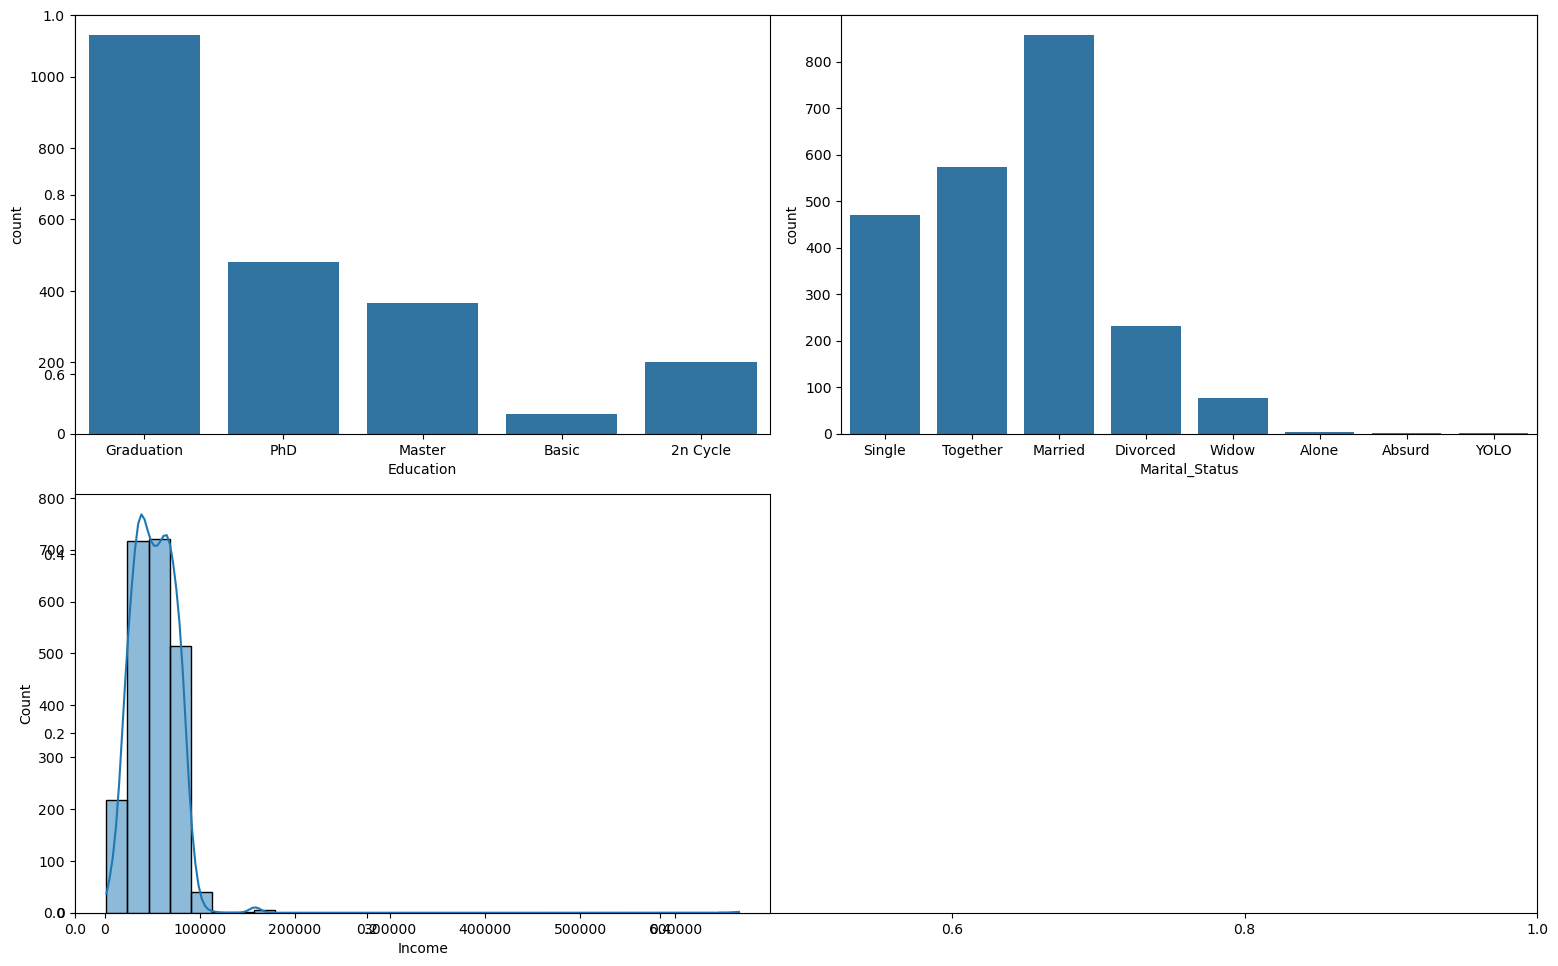

In [12]:
plt.subplots(figsize=(16, 10))

# plot the categorical columns as count plots, and Income as a histogram
plot_cols = objects + ['Income']

for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    if col == 'Income':
        sb.histplot(df[col], bins=30, kde=True)
    else:
        sb.countplot(x=df[col])

plt.tight_layout()
plt.show()

In [13]:
# check the value_counts of the Marital_Status of the data
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

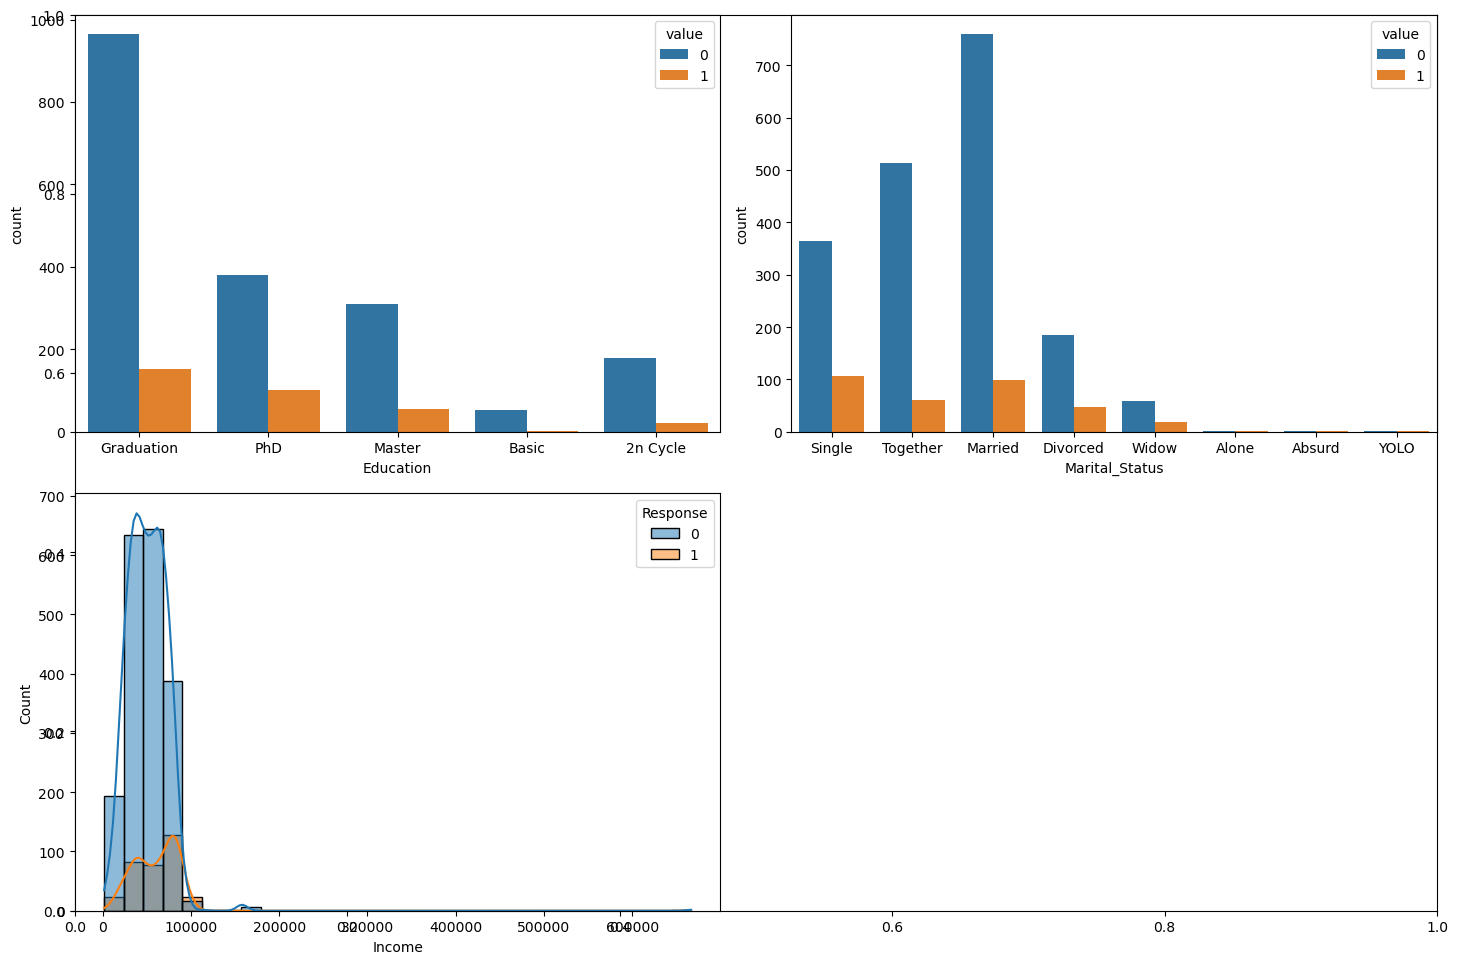

In [14]:
plt.subplots(figsize=(15, 10))

plot_cols = objects + ['Income']

for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)

    if col == 'Income':
        # Income is continuous, so show its distribution split by Response
        sb.histplot(data=df, x='Income', hue='Response', bins=30, kde=True)
    else:
        df_melted = df.melt(id_vars=[col], value_vars=['Response'], var_name='hue')
        sb.countplot(x=col, hue='value', data=df_melted)

plt.tight_layout()
plt.show()

In [23]:
# Label encoding is used to convert the categorical values into the numerical values.
for col in df.columns:
    if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

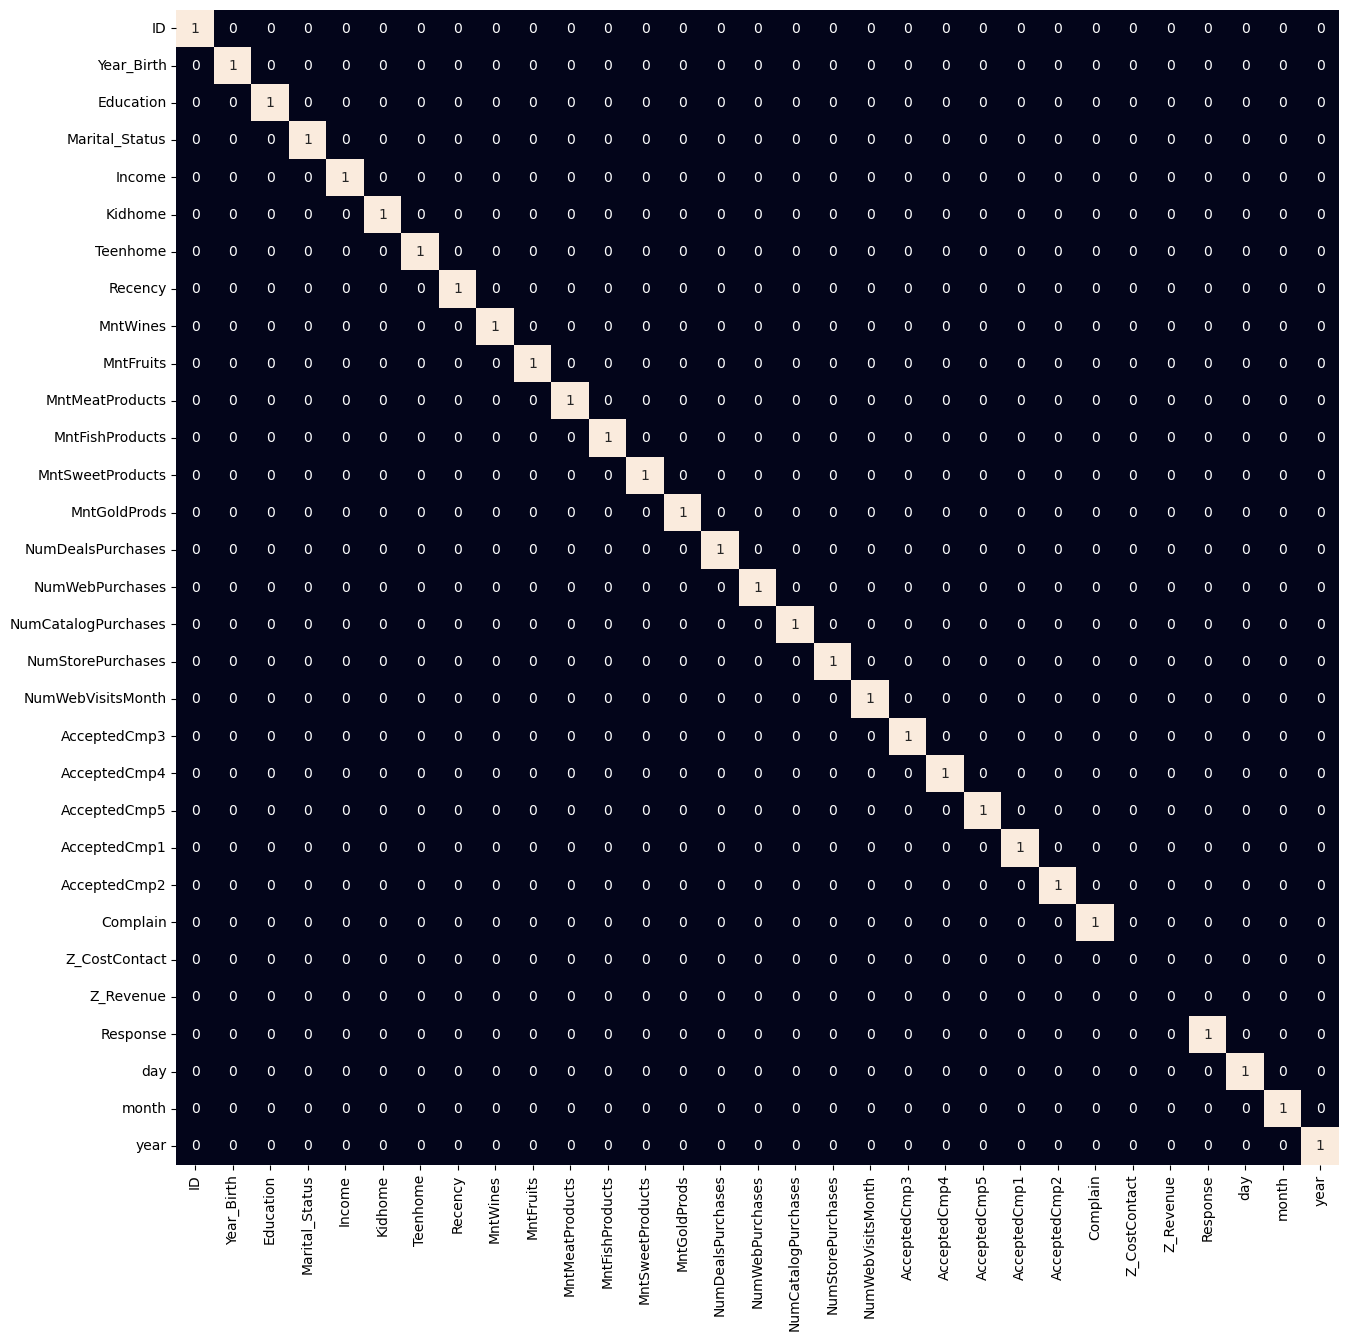

In [25]:
#heatmap
plt.figure(figsize=(15, 15))
sb.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()

In [17]:
scaler = StandardScaler()
data = scaler.fit_transform(df)

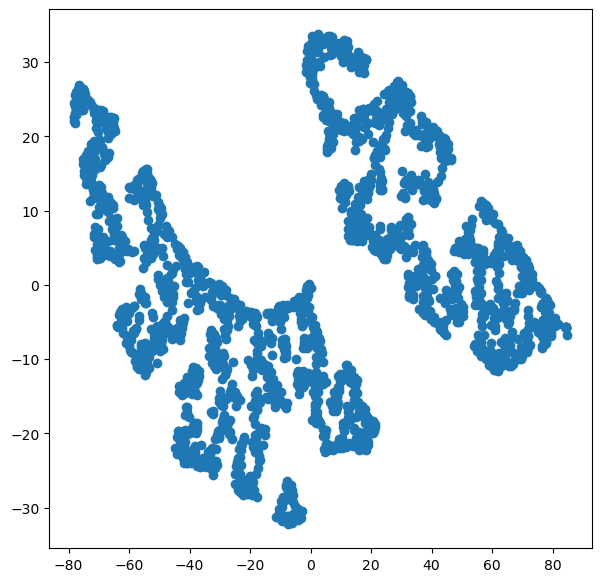

In [26]:
# creating segmentation using T-distributed Stochastic Neighbor Embedding
from sklearn.manifold import TSNE
model = TSNE(n_components=2, random_state=0)
tsne_data = model.fit_transform(df)
plt.figure(figsize=(7, 7))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1])
plt.show()


In [27]:
# using Kmeans clustering
error = []
for n_clusters in range(1, 21):
    model = KMeans(init='k-means++', 
                   n_clusters=n_clusters,
                   max_iter=500,
                   random_state=22)
    model.fit(df)
    error.append(model.inertia_)

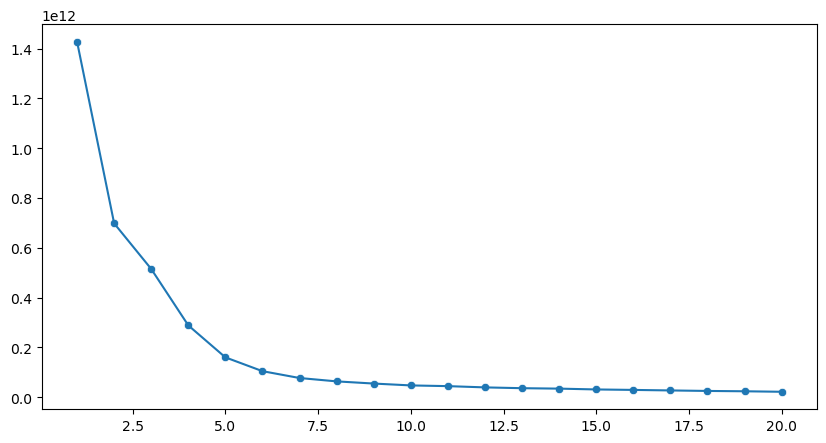

In [28]:
plt.figure(figsize=(10, 5))
sb.lineplot(x=range(1, 21), y=error)
sb.scatterplot(x=range(1, 21), y=error)
plt.show()

In [29]:
# k = 6 is the optimal number of clusters
model = KMeans(init='k-means++',
               n_clusters=5,
               max_iter=500,
               random_state=22)
segments = model.fit_predict(df)

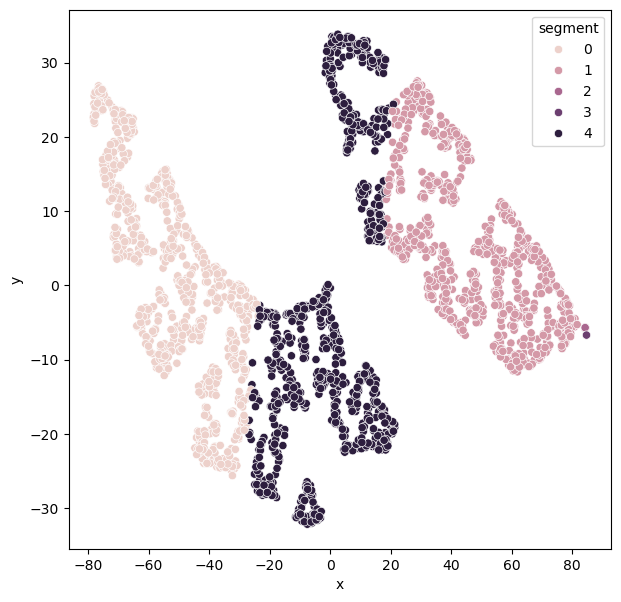

In [30]:
#Using Scatterplot to see all the 6 clusters formed by KMeans Clustering.

plt.figure(figsize=(7, 7))
df_tsne = pd.DataFrame({'x': tsne_data[:, 0], 'y': tsne_data[:, 1], 'segment': segments})

sb.scatterplot(x='x', y='y', hue='segment', data=df_tsne)
plt.show()